# Zipf Distribution

`Zipf(a, n)` is a discrete distribution on the ranks `1, 2, ..., n`, where rank `k` has probability proportional to `1 / k ** a`. A larger `a` puts more probability on the first few ranks; `a = 0` makes every rank equally likely. The support is finite: a `Zipf(a, n)` never produces a value above `n`.

In [1]:
from symbulate import *

## Draw a value from a Zipf distribution

In [2]:
Zipf(a=1.2, n=10).draw()

7

## Theoretical mean, variance, and standard deviation

All three are always finite, since there are only `n` possible values.

In [3]:
Zipf(a=1.2, n=10).mean(), Zipf(a=1.2, n=10).var(), Zipf(a=1.2, n=10).sd()

(np.float64(3.026070014612279),
 np.float64(6.293660525340199),
 np.float64(2.5087169081704292))

## The pmf

The probabilities over `1, ..., n` add to 1, and anything above `n` is exactly 0.

In [4]:
Zipf(a=1.2, n=10).pmf(1), Zipf(a=1.2, n=10).pmf(10), Zipf(a=1.2, n=10).pmf(11)

(np.float64(0.4052334497650483),
 np.float64(0.02556850213583027),
 np.float64(0.0))

## Assign and simulate a random variable

In [5]:
X = RV(Zipf(a=1.2, n=10))
X.sim(10000)

0,10
1,2
2,1
3,1
4,1
5,1
6,4
7,8
8,2
...,...
9999,6


## Plot the pmf

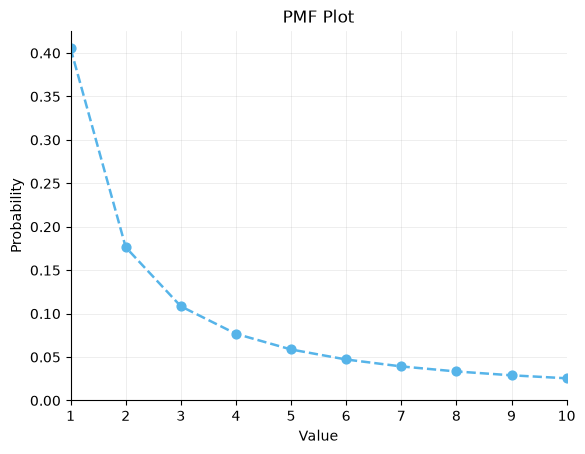

In [6]:
Zipf(a=1.2, n=10).plot()

## Plot the CDF

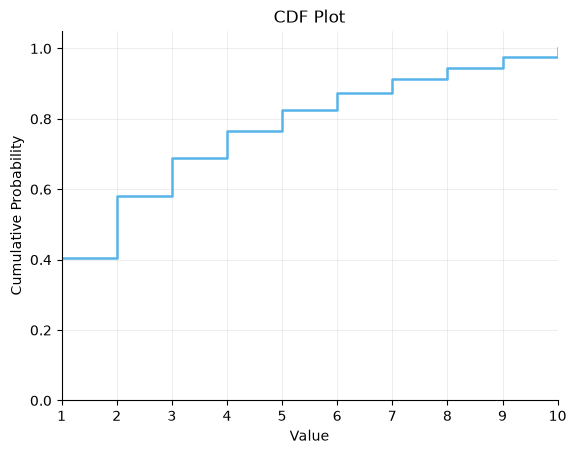

In [7]:
Zipf(a=1.2, n=10).plot(cdf=True)

## Shape parameter changes the concentration

A larger `a` piles probability onto the first few ranks and thins the tail; `a = 0` is flat.

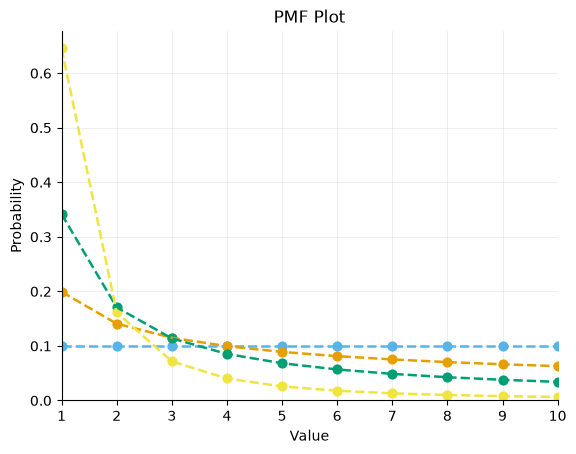

In [8]:
for a in [0, 0.5, 1, 2]:
    Zipf(a=a, n=10).plot()

## Zipf vs. Zeta: finite vs. infinite support

SciPy's naming is a trap. `scipy.stats.zipfian(a, n)` is the finite-support Zipf, which is what Symbulate's `Zipf` wraps; `scipy.stats.zipf(a)` is the *zeta* distribution, supported on `1, 2, 3, ...` with no upper limit. Symbulate has no `Zeta` yet, so the cells below call SciPy for the zeta side.

In [9]:
from scipy.stats import zipf as zeta   # SciPy's "zipf" is really the zeta distribution

Zipf(a=2, n=10).pmf(11), zeta.pmf(11, 2)   # above n: impossible vs. still possible

(np.float64(0.0), np.float64(0.005024190924413443))

Growing `n` with `a > 1` turns a Zipf into a zeta. For `a <= 1` the infinite sum diverges, so the zeta does not exist and only the finite version does.

In [10]:
Zipf(a=2, n=10).pmf(1), Zipf(a=2, n=100000).pmf(1), zeta.pmf(1, 2), zeta.pmf(1, 0.8)

(np.float64(0.6452579827864142),
 np.float64(0.6079307976116269),
 np.float64(0.6079271018540265),
 np.float64(nan))

## Relationship: chopping a zeta off at `n` gives a Zipf

Keep only the zeta values at or below `n` and what survives is exactly `Zipf(a, n)`. Requires `a > 1`, so the zeta exists.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


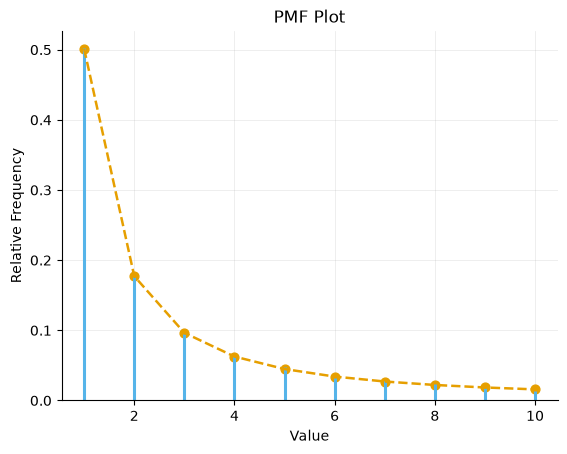

In [11]:
Z = RV(ProbabilitySpace(lambda: int(zeta.rvs(1.5))))
Z.sim(20000).filter(lambda k: k <= 10).plot()
Zipf(a=1.5, n=10).plot()

## Relationship: `a = 0` is a discrete uniform

With `a = 0` every rank is equally likely, so `Zipf(0, n)` is exactly `DiscreteUniform(1, n)`.

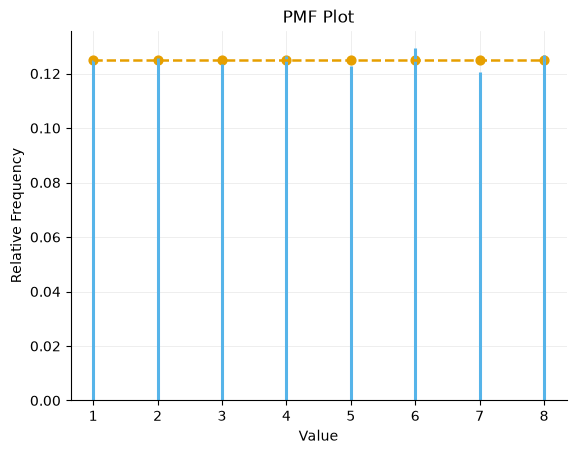

In [12]:
U = RV(DiscreteUniform(a=1, b=8))
U.sim(10000).plot()
Zipf(a=0, n=8).plot()

## Relationship: a `BoxModel` with power-law weights

A Zipf is a weighted draw from `1, ..., n` with weight `1 / k ** a` on rank `k`, normalized to add to 1.

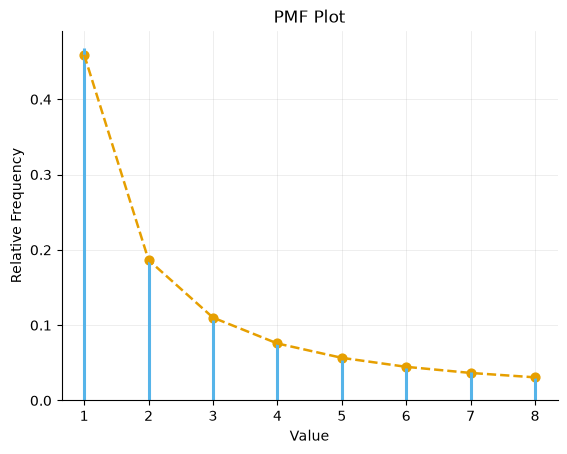

In [13]:
weights = [k**-1.3 for k in range(1, 9)]
B = RV(BoxModel(list(range(1, 9)), probs=[w / sum(weights) for w in weights]))
B.sim(10000).plot()
Zipf(a=1.3, n=8).plot()

## Relationship: with two ranks, a Zipf is a shifted Bernoulli

`Zipf(a, 2)` is `1 + Bernoulli(p)`, where `p = 2 ** -a / (1 + 2 ** -a)` is the chance of rank 2.

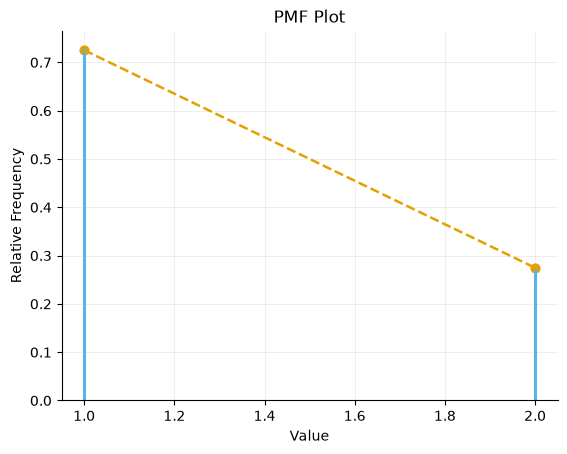

In [14]:
Y = RV(Bernoulli(2**-1.4 / (1 + 2**-1.4)))
(1 + Y).sim(10000).plot()
Zipf(a=1.4, n=2).plot()